# 🌾 Lab 3 — Implementation of Neural Network
## Crop Yield Prediction using Feedforward Neural Network

---

### 📋 Lab Overview

| Field | Details |
|---|---|
| **Lab Name** | Implementation of Neural Network |
| **Dataset** | Synthetic Agricultural Crop Dataset (1200 records) |
| **Domain** | Precision Agriculture / Regression |
| **Tools Used** | NumPy, Pandas, Scikit-learn, TensorFlow / Keras, Matplotlib |

---

### 🎯 Problem Statement

> **Can we predict the crop yield (tonnes/hectare) of a farm plot based on environmental and agronomic factors such as rainfall, temperature, soil pH, fertilizer usage, and sunlight hours?**
>
> Accurate yield prediction enables farmers to optimize resources, reduce waste, and improve food security. In this lab, we build a Feedforward Neural Network (FNN) trained on synthetic but realistic agricultural data to perform regression-based crop yield prediction.

### 🎓 Learning Objectives
- Understand the architecture of a Feedforward Neural Network (FNN)
- Preprocess tabular data — encoding, scaling, and splitting
- Build, compile and train a regression neural network using Keras
- Evaluate model performance using MAE, MSE, and R² Score
- Visualize training loss curves and prediction vs actual plots

---
## 📦 Section 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print('✅ All libraries imported!')
print(f'   TensorFlow : {tf.__version__}')
print(f'   Keras      : {keras.__version__}')

✅ All libraries imported!
   TensorFlow : 2.19.0
   Keras      : 3.10.0


---
## 🌱 Section 2: Dataset Generation

We generate a **synthetic agricultural dataset** of 1200 farm plots with the following features:

| Feature | Description |
|---|---|
| `crop_type` | Type of crop (Wheat, Rice, Maize, Soybean, Cotton) |
| `rainfall_mm` | Annual rainfall in millimeters |
| `temperature_c` | Average temperature in °C |
| `soil_ph` | Soil pH level (4.5 – 8.5) |
| `fertilizer_kg_ha` | Fertilizer used in kg/hectare |
| `sunlight_hours` | Average daily sunlight hours |
| `irrigation` | Irrigation availability (Yes/No) |
| `soil_type` | Soil type (Sandy, Loamy, Clay, Silt) |
| `yield_tonnes_ha` | **Target**: Crop yield in tonnes/hectare |

In [2]:
np.random.seed(7)
N = 1200

crop_types  = ['Wheat','Rice','Maize','Soybean','Cotton']
soil_types  = ['Sandy','Loamy','Clay','Silt']
irrigation  = np.random.choice(['Yes','No'], N, p=[0.6, 0.4])
crop_arr    = np.random.choice(crop_types, N)
soil_arr    = np.random.choice(soil_types, N)

rainfall    = np.clip(np.random.normal(700, 200, N), 200, 1500).round(1)
temperature = np.clip(np.random.normal(25, 6, N), 10, 42).round(1)
soil_ph     = np.clip(np.random.normal(6.5, 0.8, N), 4.5, 8.5).round(2)
fertilizer  = np.clip(np.random.normal(180, 60, N), 50, 400).round(1)
sunlight    = np.clip(np.random.normal(7, 1.5, N), 3, 12).round(1)

# Yield depends on rainfall, fertilizer, irrigation, temperature (inverted U)
irr_factor  = np.where(irrigation == 'Yes', 1.3, 1.0)
yield_val   = (
    0.004 * rainfall +
    0.015 * fertilizer +
    0.3   * sunlight -
    0.02  * np.abs(temperature - 25) +
    irr_factor * 0.8 +
    np.random.normal(0, 0.5, N)
)
yield_val = np.clip(yield_val, 0.5, 12.0).round(2)

df = pd.DataFrame({
    'crop_type'        : crop_arr,
    'rainfall_mm'      : rainfall,
    'temperature_c'    : temperature,
    'soil_ph'          : soil_ph,
    'fertilizer_kg_ha' : fertilizer,
    'sunlight_hours'   : sunlight,
    'irrigation'       : irrigation,
    'soil_type'        : soil_arr,
    'yield_tonnes_ha'  : yield_val
})

print(f'✅ Dataset: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'   Yield range: {yield_val.min():.2f} – {yield_val.max():.2f} tonnes/ha')
df.head()

✅ Dataset: 1200 rows x 9 columns
   Yield range: 4.13 – 12.00 tonnes/ha


,crop_type,rainfall_mm,temperature_c,soil_ph,fertilizer_kg_ha,sunlight_hours,irrigation,soil_type,yield_tonnes_ha
0,Maize,783.1,27.3,6.63,199.8,6.2,Yes,Sandy,9.69
1,Wheat,845.0,29.2,5.86,144.0,8.1,No,Clay,8.96
2,Wheat,859.9,29.4,7.08,130.1,10.8,Yes,Loamy,9.32
3,Maize,601.4,28.1,7.19,190.6,9.0,No,Silt,8.25
4,Cotton,404.1,29.9,7.62,177.8,7.8,No,Loamy,6.89


---
## 🔍 Section 3: Exploratory Data Analysis

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   crop_type         1200 non-null   object 
 1   rainfall_mm       1200 non-null   float64
 2   temperature_c     1200 non-null   float64
 3   soil_ph           1200 non-null   float64
 4   fertilizer_kg_ha  1200 non-null   float64
 5   sunlight_hours    1200 non-null   float64
 6   irrigation        1200 non-null   object 
 7   soil_type         1200 non-null   object 
 8   yield_tonnes_ha   1200 non-null   float64
dtypes: float64(6), object(3)
memory usage: 84.5+ KB

=== Statistical Summary ===


,rainfall_mm,temperature_c,soil_ph,fertilizer_kg_ha,sunlight_hours,yield_tonnes_ha
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,705.87,24.87,6.50,181.49,7.03,8.53
std,196.22,5.83,0.78,60.23,1.51,1.42
min,200.00,10.00,4.50,50.00,3.00,4.13
25%,568.48,20.70,5.96,139.78,6.00,7.52
50%,703.55,25.00,6.49,181.00,7.10,8.60
75%,836.62,28.80,7.03,222.55,8.10,9.54
max,1329.00,42.00,8.50,378.20,11.90,12.00



Missing values: 0


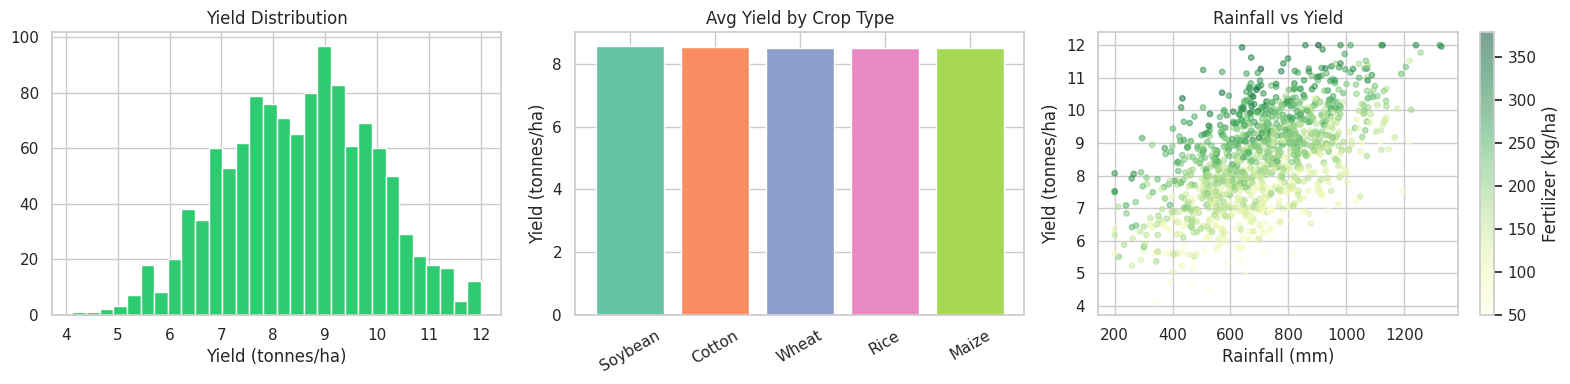

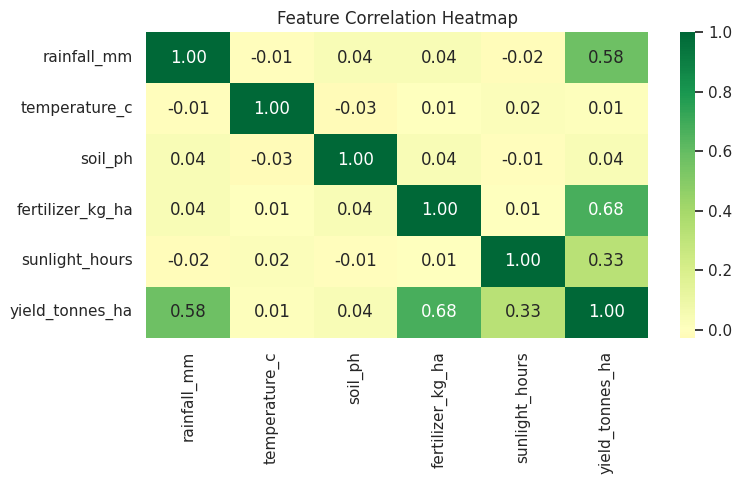

In [3]:
print('=== Dataset Info ===')
df.info()
print('\n=== Statistical Summary ===')
display(df.describe().round(2))
print(f'\nMissing values: {df.isnull().sum().sum()}')

# Yield distribution by crop type
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Yield distribution
axes[0].hist(df['yield_tonnes_ha'], bins=30, color='#2ECC71', edgecolor='white')
axes[0].set_title('Yield Distribution')
axes[0].set_xlabel('Yield (tonnes/ha)')

# Average yield by crop
crop_yield = df.groupby('crop_type')['yield_tonnes_ha'].mean().sort_values(ascending=False)
axes[1].bar(crop_yield.index, crop_yield.values, color=sns.color_palette('Set2'))
axes[1].set_title('Avg Yield by Crop Type')
axes[1].set_ylabel('Yield (tonnes/ha)')
axes[1].tick_params(axis='x', rotation=30)

# Rainfall vs Yield scatter
sc = axes[2].scatter(df['rainfall_mm'], df['yield_tonnes_ha'],
                      c=df['fertilizer_kg_ha'], cmap='YlGn', alpha=0.5, s=15)
plt.colorbar(sc, ax=axes[2], label='Fertilizer (kg/ha)')
axes[2].set_title('Rainfall vs Yield')
axes[2].set_xlabel('Rainfall (mm)')
axes[2].set_ylabel('Yield (tonnes/ha)')

plt.tight_layout()
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(8,5))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

---
## ⚙️ Section 4: Data Preprocessing

In [4]:
# 1. Encode categorical features
le_crop = LabelEncoder()
le_soil = LabelEncoder()
le_irr  = LabelEncoder()

df_enc = df.copy()
df_enc['crop_type']  = le_crop.fit_transform(df['crop_type'])
df_enc['soil_type']  = le_soil.fit_transform(df['soil_type'])
df_enc['irrigation'] = le_irr.fit_transform(df['irrigation'])

print('Encoded classes:')
print(f'  Crop types : {list(le_crop.classes_)}')
print(f'  Soil types : {list(le_soil.classes_)}')
print(f'  Irrigation : {list(le_irr.classes_)}')

# 2. Split features and target
X = df_enc.drop('yield_tonnes_ha', axis=1).values
y = df_enc['yield_tonnes_ha'].values

# 3. Train/Validation/Test split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'\nSplit sizes — Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')

# 4. Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print('✅ Data preprocessed and scaled.')

Encoded classes:
  Crop types : ['Cotton', 'Maize', 'Rice', 'Soybean', 'Wheat']
  Soil types : ['Clay', 'Loamy', 'Sandy', 'Silt']
  Irrigation : ['No', 'Yes']

Split sizes — Train: 840 | Val: 180 | Test: 180
✅ Data preprocessed and scaled.


---
## 🧠 Section 5: Build the Neural Network

### Architecture
```
Input Layer  →  8 features
Hidden Layer 1 → 128 neurons, ReLU, BatchNorm, Dropout(0.3)
Hidden Layer 2 → 64 neurons,  ReLU, BatchNorm, Dropout(0.2)
Hidden Layer 3 → 32 neurons,  ReLU
Output Layer  →  1 neuron (yield prediction)
```

In [5]:
def build_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(32, activation='relu', kernel_initializer='he_normal'),

        layers.Dense(1, activation='linear')  # Regression output
    ], name='CropYield_FNN')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

model = build_model(X_train.shape[1])
model.summary()

Model: "CropYield_FNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 384 (1.50 KB)

---
## 🏋️ Section 6: Train the Model

In [6]:
# Callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

print(f'\n✅ Training complete. Best epoch: {np.argmin(history.history["val_loss"]) + 1}')

Epoch 1/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 60.2376 - mae: 7.5297 - val_loss: 57.1647 - val_mae: 7.4863 - learning_rate: 0.0010
Epoch 2/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 31.9357 - mae: 5.3990 - val_loss: 29.9451 - val_mae: 5.3316 - learning_rate: 0.0010
Epoch 3/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14.1203 - mae: 3.3823 - val_loss: 14.4190 - val_mae: 3.5805 - learning_rate: 0.0010
Epoch 4/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.8553 - mae: 2.2034 - val_loss: 7.3506 - val_mae: 2.4509 - learning_rate: 0.0010
Epoch 5/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9178 - mae: 1.5982 - val_loss: 4.0704 - val_mae: 1.7706 - learning_rate: 0.0010
Epoch 6/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.0862 - mae: 1.3643 - val_loss: 2.7261 - val_mae: 1.4183 - learning_rate: 0.0010
Epoch 7/150
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.6455 - mae: 1.3058 - val_loss: 1.7615 - val_mae: 1.0943 - learning_rate: 0.0010
Epoch 

---
## 📊 Section 7: Evaluation & Visualization

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
=== Model Performance on Test Set ===
   MAE  : 0.5200 tonnes/ha
   MSE  : 0.4259
   RMSE : 0.6526 tonnes/ha
   R²   : 0.7504


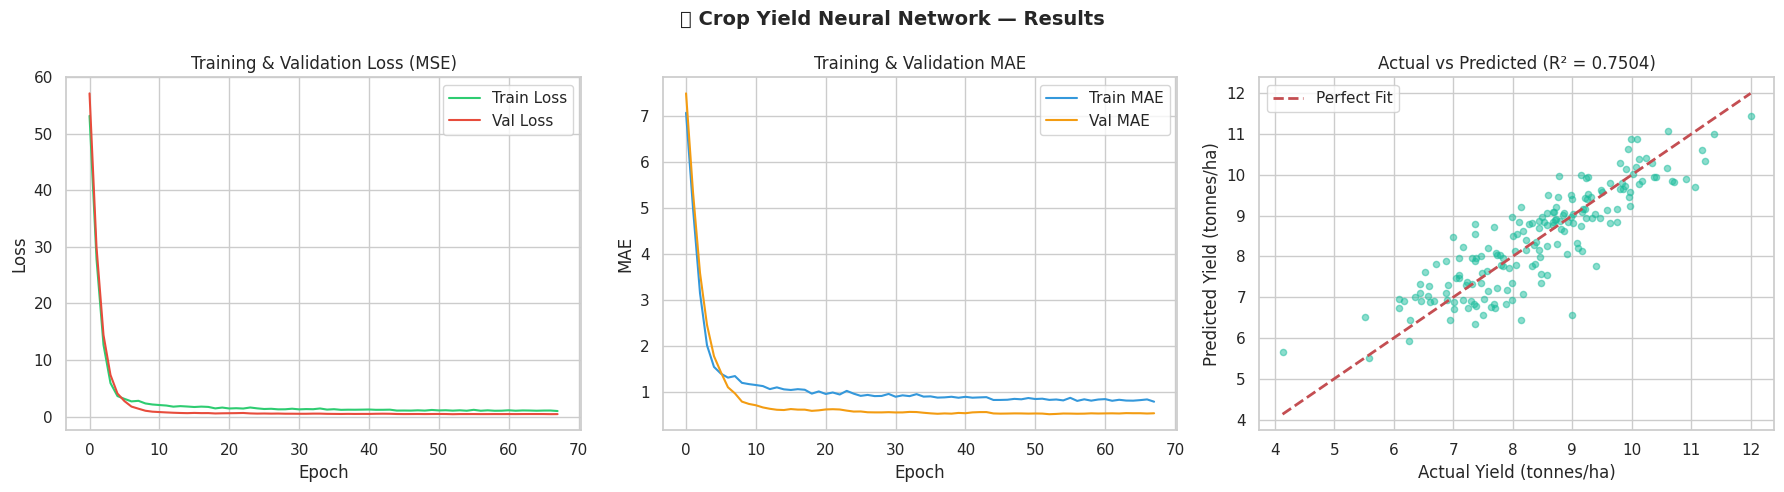

In [7]:
# Predictions
y_pred = model.predict(X_test).flatten()

# Metrics
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('=== Model Performance on Test Set ===')
print(f'   MAE  : {mae:.4f} tonnes/ha')
print(f'   MSE  : {mse:.4f}')
print(f'   RMSE : {rmse:.4f} tonnes/ha')
print(f'   R²   : {r2:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(history.history['loss'],     label='Train Loss', color='#2ECC71')
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#E74C3C')
axes[0].set_title('Training & Validation Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# MAE curves
axes[1].plot(history.history['mae'],     label='Train MAE', color='#3498DB')
axes[1].plot(history.history['val_mae'], label='Val MAE',   color='#F39C12')
axes[1].set_title('Training & Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

# Actual vs Predicted
axes[2].scatter(y_test, y_pred, alpha=0.5, s=20, color='#1ABC9C')
min_v, max_v = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[2].plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect Fit')
axes[2].set_title(f'Actual vs Predicted (R² = {r2:.4f})')
axes[2].set_xlabel('Actual Yield (tonnes/ha)')
axes[2].set_ylabel('Predicted Yield (tonnes/ha)')
axes[2].legend()

plt.suptitle('🌾 Crop Yield Neural Network — Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔎 Section 8: Sample Predictions & Residual Analysis

=== Sample Predictions ===


,Actual (t/ha),Predicted (t/ha),Error
0,9.40,7.77,1.63
1,8.18,8.63,-0.45
2,8.93,8.84,0.09
3,6.18,6.92,-0.74
4,8.08,8.54,-0.46
5,9.64,9.80,-0.16
6,8.80,8.87,-0.07
7,9.24,8.95,0.29
8,10.37,9.94,0.43
9,7.16,6.94,0.22


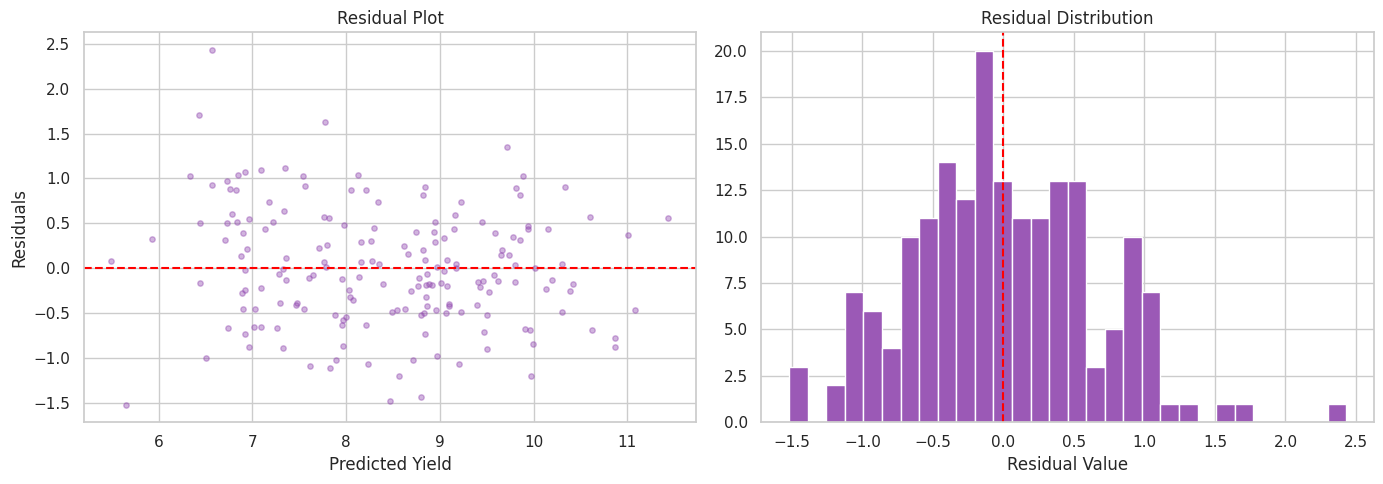


✅ Lab 3 Complete!
   Final R² Score: 0.7504 — Model explains 75.0% of yield variance


In [8]:
# Sample predictions table
results_df = pd.DataFrame({
    'Actual (t/ha)'   : y_test[:15].round(2),
    'Predicted (t/ha)': y_pred[:15].round(2),
    'Error'           : (y_test[:15] - y_pred[:15]).round(2)
})
print('=== Sample Predictions ===')
display(results_df)

# Residual plot
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, residuals, alpha=0.4, s=15, color='#8E44AD')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residual Plot')
axes[0].set_xlabel('Predicted Yield')
axes[0].set_ylabel('Residuals')

axes[1].hist(residuals, bins=30, color='#9B59B6', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual Value')

plt.tight_layout()
plt.show()

print(f'\n✅ Lab 3 Complete!')
print(f'   Final R² Score: {r2:.4f} — Model explains {r2*100:.1f}% of yield variance')